# 3. Обработка пленоптических фотографий

Данное задание состоит двух основных частей. **Оно не является конкурсным**, за каждое подзадание можно получить максимальное качество баллов за приемлемую работу. Интересные мысли и красивая реализация приветствуются.

## Часть 1. Lytro Light Field Camera (8 баллов)

![plenoptic_small.jpg](plenoptic_small.jpg)

В 2011 году появилась камера Lytro Light Field Camera. Вот краткое описание формата пикселей:
* Базовое разрешение 3280x3280
* Линзы в массиве упакованы "как соты" (поэтому каждый второй ряд на полпикселя сдвинут относительно другого)
* Под каждой линзой количество пикселей по высоте и ширине не является целым
* Более того, этот массив микролинз немного повёрнут относительно массива пикселей

В этой части задания мы попробуем руками получить хоть что-то красивое из сырых изображений, а также научимся сдвигать наблюдателя в плоскости объектива

**Для начала откроем изображение**

In [ ]:
import imageio
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import Image
from skimage import io
from skimage.util import img_as_float, img_as_ubyte

%matplotlib inline

In [ ]:
image = img_as_float(io.imread('bee.png'))

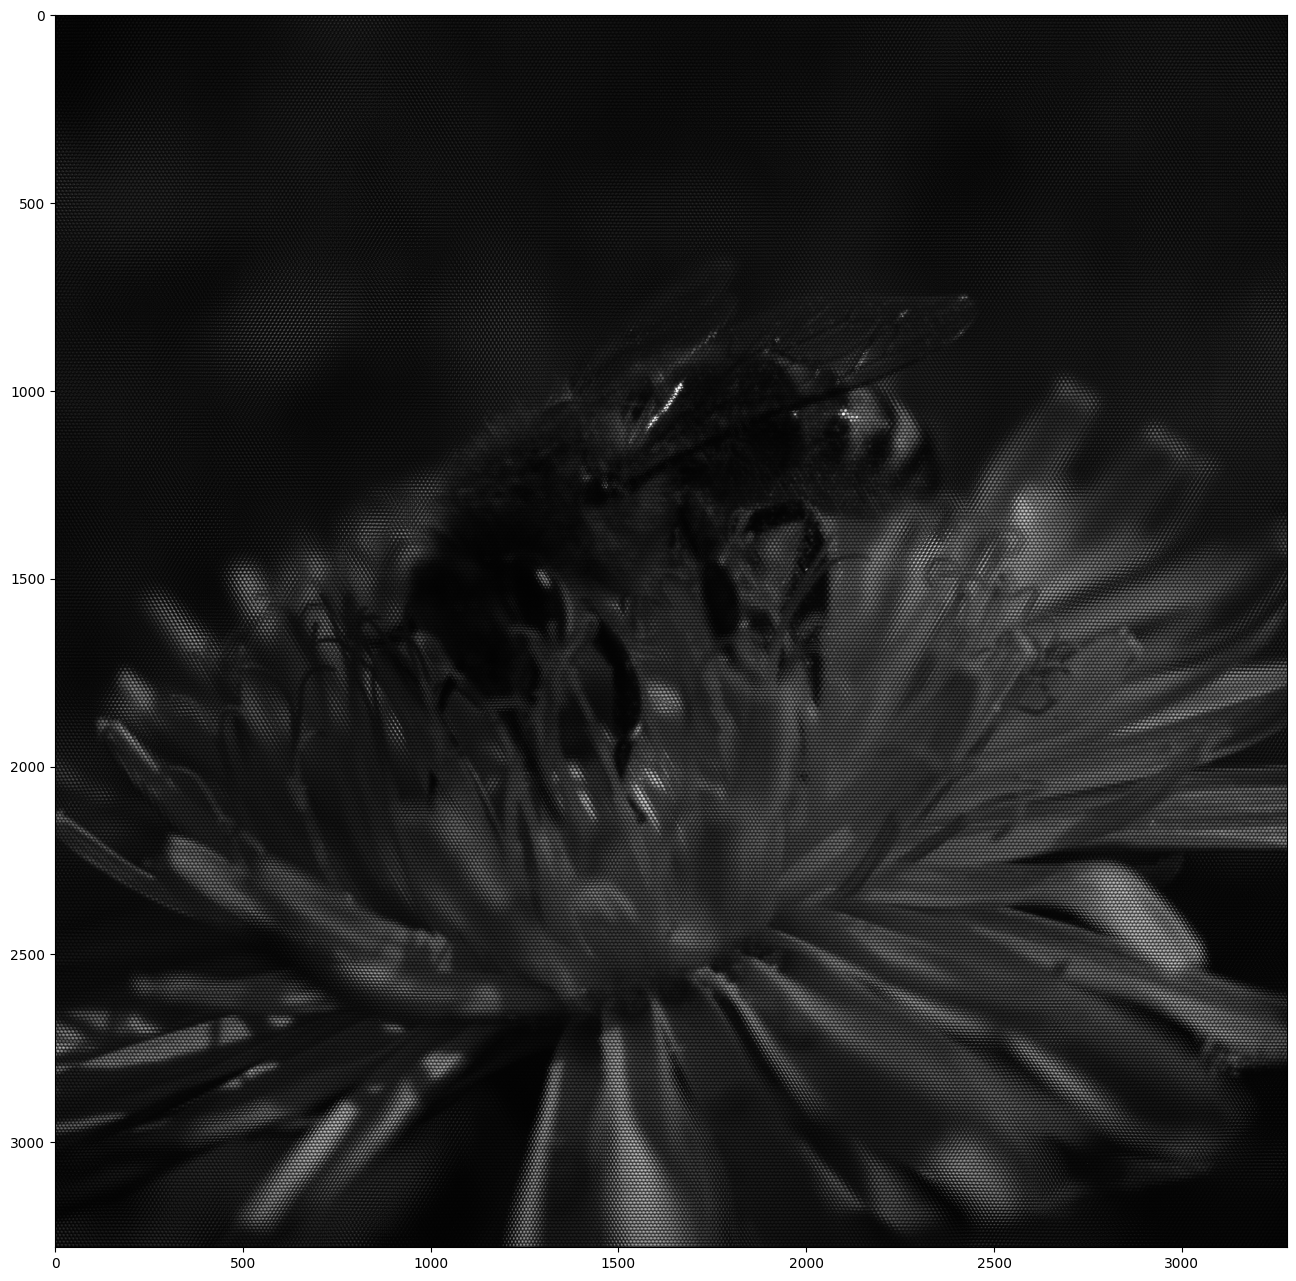

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(image, cmap='gray')
plt.show()

Увеличим его часть:

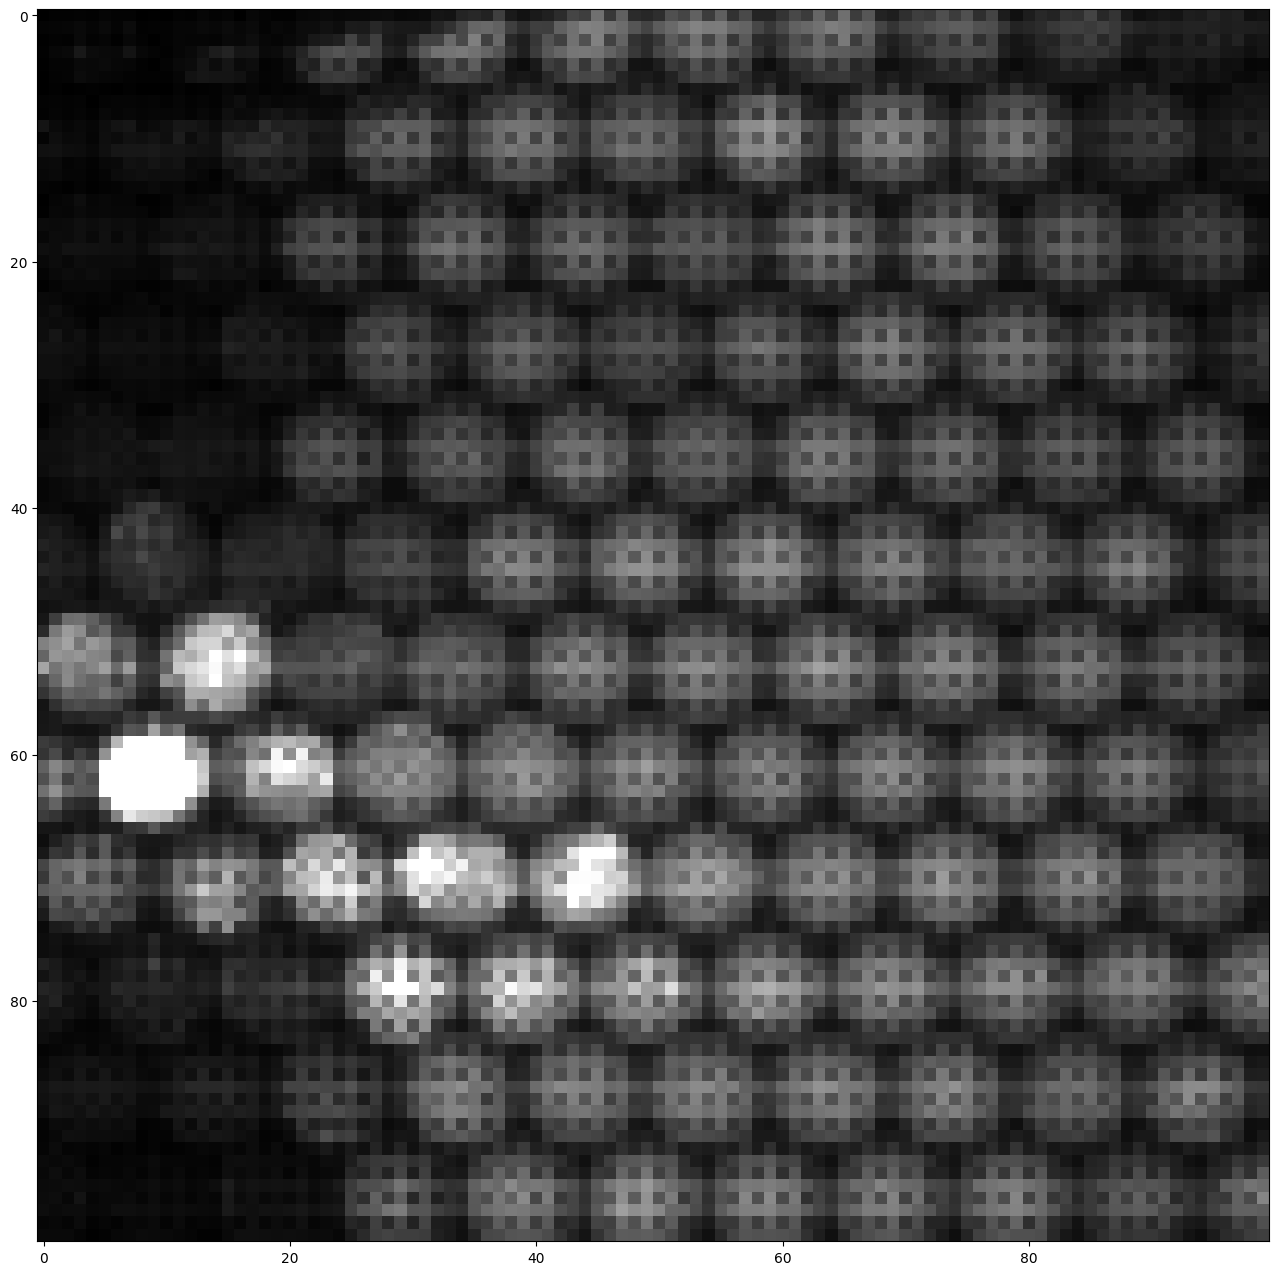

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(image[1000:1100, 2090:2190], cmap='gray')
plt.show()

Чётко прослеживается структура массива линз, кроме того, видим, что и внутри линз есть своя структура - некоторые пиксели регулярно темнее/светлее остальных. Дело в том, что изначально каждый фотодиод фотоматрицы принимает только определённый цвет изображения, так как [накрыт цветным фильтром](https://ru.wikipedia.org/wiki/%D0%A4%D0%B8%D0%BB%D1%8C%D1%82%D1%80_%D0%91%D0%B0%D0%B9%D0%B5%D1%80%D0%B0).

Преобразуем сырые данные камеры в RGB-изображение. Для этого:
* Составим маску красных, синих и зелёных каналов на сыром изображении
* Произведём интерполяцию путём усреднения соседних известных значений канала

Первый шаг - составление маски. Начиная с левого верхнего угла, цвет хранится так:
<table><tr><td bgcolor="#0000FF"></td><td bgcolor="#00FF00"></td></tr><tr><td bgcolor="#00FF00"></td><td bgcolor="#FF0000"></td></tr></table>
Напишите функцию, которая по заданной высоте и ширине изображения составит маски каналов (4 матрицы, значение элемента внутри которых равно единице в пикселях, который содержит B, G1, G2 или R компоненту соответственно).

Например, для изображения $2 \times 2$ матрица для цветовой компоненты B выглядит так:

$$
\begin{pmatrix}
1 & 0 \\
0 & 0
\end{pmatrix}
$$

Обратите внимание, что G-канал разделён на два для последующего удобства обработки.

In [ ]:
def get_bayer_pattern_masks(h, w):
    '''
    Возвращает 4 маски заданной высоты и ширины для сырого изображения формата
    B G1
    G2 R
    '''
    b_base = np.array([[1, 0], [0, 0]])
    g1_base = np.array([[0, 1], [0, 0]])
    g2_base = np.array([[0, 0], [1, 0]])
    r_base = np.array([[0, 0], [0, 1]])

    reps = ((h + 1) // 2, (w + 1) // 2)

    mask_b = np.tile(b_base, reps)[:h, :w]
    mask_g1 = np.tile(g1_base, reps)[:h, :w]
    mask_g2 = np.tile(g2_base, reps)[:h, :w]
    mask_r = np.tile(r_base, reps)[:h, :w]

    return [mask_b, mask_g1, mask_g2, mask_r]

Следующий шаг - интерполяция каналов. Действовать будем по [этой статье](https://www.researchgate.net/profile/Henrique-Malvar/publication/4087683_High-quality_linear_interpolation_for_demosaicing_of_Bayer-patterned_color_images/links/0fcfd50d1e1b44b180000000/High-quality-linear-interpolation-for-demosaicing-of-Bayer-patterned-color-images.pdf). Суть её заключается в том, что для каждого из четырёх типов пикселей мы вычисляем веса неизвестных каналов следующим способом:

![bayer_interpolation.png](bayer_interpolation.png)

In [ ]:
from scipy.ndimage import convolve

def high_quality_bayer_interpolation(raw_image):
    h, w = raw_image.shape

    weights_0 = (1 / 8) * np.array([[0, 0, 0.5, 0, 0], [0, -1, 0, -1, 0], [-1, 4, 5, 4, -1], [0, -1, 0, -1, 0], [0, 0, 0.5, 0, 0]])
    weights_1 = (1 / 8) * np.array([[0, 0, -1, 0, 0], [0, -1, 4, -1, 0], [0.5, 0, 5, 0, 0.5], [0, -1, 4, -1, 0], [0, 0, -1, 0, 0]])
    weights_2 = (1 / 8) * np.array([[0, 0, -1.5, 0, 0], [0, 2, 0, 2, 0], [-1.5, 0, 6, 0, -1.5], [0, 2, 0, 2, 0], [0, 0, -1.5, 0, 0]])
    weights_3 = (1 / 8) * np.array([[0, 0, -1, 0, 0], [0, 0, 2, 0, 0], [-1, 2, 4, 2, -1], [0, 0, 2, 0, 0], [0, 0, -1, 0, 0]])

    mask_b, mask_g1, mask_g2, mask_r = get_bayer_pattern_masks(h, w)
    mask_g = mask_g1 + mask_g2

    g_interp = convolve(raw_image, weights_3)
    image_g = raw_image * mask_g + g_interp * (mask_r + mask_b)

    r_at_g_row = convolve(raw_image, weights_1)
    r_at_g_col = convolve(raw_image, weights_0)
    r_at_b = convolve(raw_image, weights_2)
    image_r = raw_image * mask_r + r_at_g_row * mask_g1 + r_at_g_col * mask_g2 + r_at_b * mask_b

    b_at_g_row = convolve(raw_image, weights_0)
    b_at_g_col = convolve(raw_image, weights_1)
    b_at_r = convolve(raw_image, weights_2)
    image_b = raw_image * mask_b + b_at_g_row * mask_g1 + b_at_g_col * mask_g2 + b_at_r * mask_r

    image = np.stack([image_r, image_g, image_b], axis=-1)
    return np.clip(image, 0, 1)

In [ ]:
raw_data = img_as_float(io.imread('bee.png'))
if len(raw_data.shape) == 3:
    raw_data = raw_data[:, :, 0]

image_interpolated = high_quality_bayer_interpolation(raw_data)

In [ ]:
plt.figure(figsize=(32, 32))
plt.imshow(image_interpolated)
plt.show()

**Ура!** Теперь осталось его правильно обработать. Давайте реализуем сдвиг по вертикали и горизонтали.

В простейшем случае процесс описан в [этой ссылке](http://www.plenoptic.info/pages/sub-aperture.html) (только параграф про получение Sub-apertures!). По сути, нужно выбрать пиксели внутри каждого блока с некоторым сдвигом. Для получения значения пикселя в нецелых координатах можно использовать [билинейную интерполяцию](https://en.wikipedia.org/wiki/Bilinear_interpolation) (см. раздел Computation / On the unit square)

In [ ]:
plenoptic_image_config = {
    'block_width': 9.927582228653469,
    'block_height': 8.607538408172838
}

In [ ]:
def baseline_move(plenoptic_raw_image, plenoptic_image_config, position_shift_y, position_shift_x):
    raw_h, raw_w, _ = plenoptic_raw_image.shape
    bh = plenoptic_image_config['block_height']
    bw = plenoptic_image_config['block_width']

    rows = int(raw_h / bh)
    cols = int(raw_w / bw)
    result = np.zeros((rows, cols, 3))

    for r in range(rows):
        row_shift = (bw / 2) if (r % 2 == 1) else 0
        for c in range(cols):
            y = int(r * bh + bh / 2 + position_shift_y)
            x = int(c * bw + bw / 2 + row_shift + position_shift_x)

            if 0 <= y < raw_h and 0 <= x < raw_w:
                result[r, c] = plenoptic_raw_image[y, x]

    return img_as_ubyte(result)

In [ ]:
images = []
for dx in tqdm(range(-4, 5, 1)):
    for dy in range(-3, 4, 1):
        frame = baseline_move(image_interpolated, plenoptic_image_config, dy, dx)
        images.append(frame)

  0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
imageio.mimsave('baseline_move.gif', images, duration=100)

In [ ]:
with open('baseline_move.gif','rb') as f:
    display(Image(data=f.read()))

*Что ожидается увидеть: заметное движение заднего фона, однако, яркость изображений будет отличаться, это нормально. Кроме того, возможны небольшие горизонтальные/вертикальные полоски.*.

Несоответствие по яркости происходит из-за того, что через массив микролинз свет падает неравномерно на массив фотодиодов, а при дебайеринге мы никак не учитывали этот факт.
Попробуем отнормировать изображения по цвету. Для этого воспользуйтесь функцией [match_histograms](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_histogram_matching.html)


In [ ]:
from skimage.exposure import match_histograms

images = []
reference_frame = baseline_move(image_interpolated, plenoptic_image_config, 0, 0)

print("Generating normalized frames...")
for dx in tqdm(range(-4, 5, 1)):
    for dy in range(-3, 4, 1):
        frame = baseline_move(image_interpolated, plenoptic_image_config, dy, dx)
        matched_frame = match_histograms(frame, reference_frame, channel_axis=-1)
        images.append(matched_frame)

Generating normalized frames...


  0%|          | 0/9 [00:00<?, ?it/s]

In [ ]:
imageio.mimsave('baseline_move_with_histograms.gif', images, duration=100)

In [ ]:
with open('baseline_move_with_histograms.gif', 'rb') as f:
    display(Image(data=f.read()))

## Часть 2. Немного 3D (7 баллов)

В этом подзадании требуется получить [анаглифное](https://ru.wikipedia.org/wiki/%D0%90%D0%BD%D0%B0%D0%B3%D0%BB%D0%B8%D1%84) изображение на основе полученных данных. План приблизительно следующий:
* Создайте два изображения с максимальным параллаксом (горизонтальным расстоянием между виртуальными камерами)
* Наложите их друг на друга, используя цветовые фильтры
* Получите ещё больше баллов за небольшой анализ (пробуйте уменьшать/увеличивать параллакс, создаёте gif-картинку). Что будет, если изначально накладывать изображения с небольшим сдвигом?

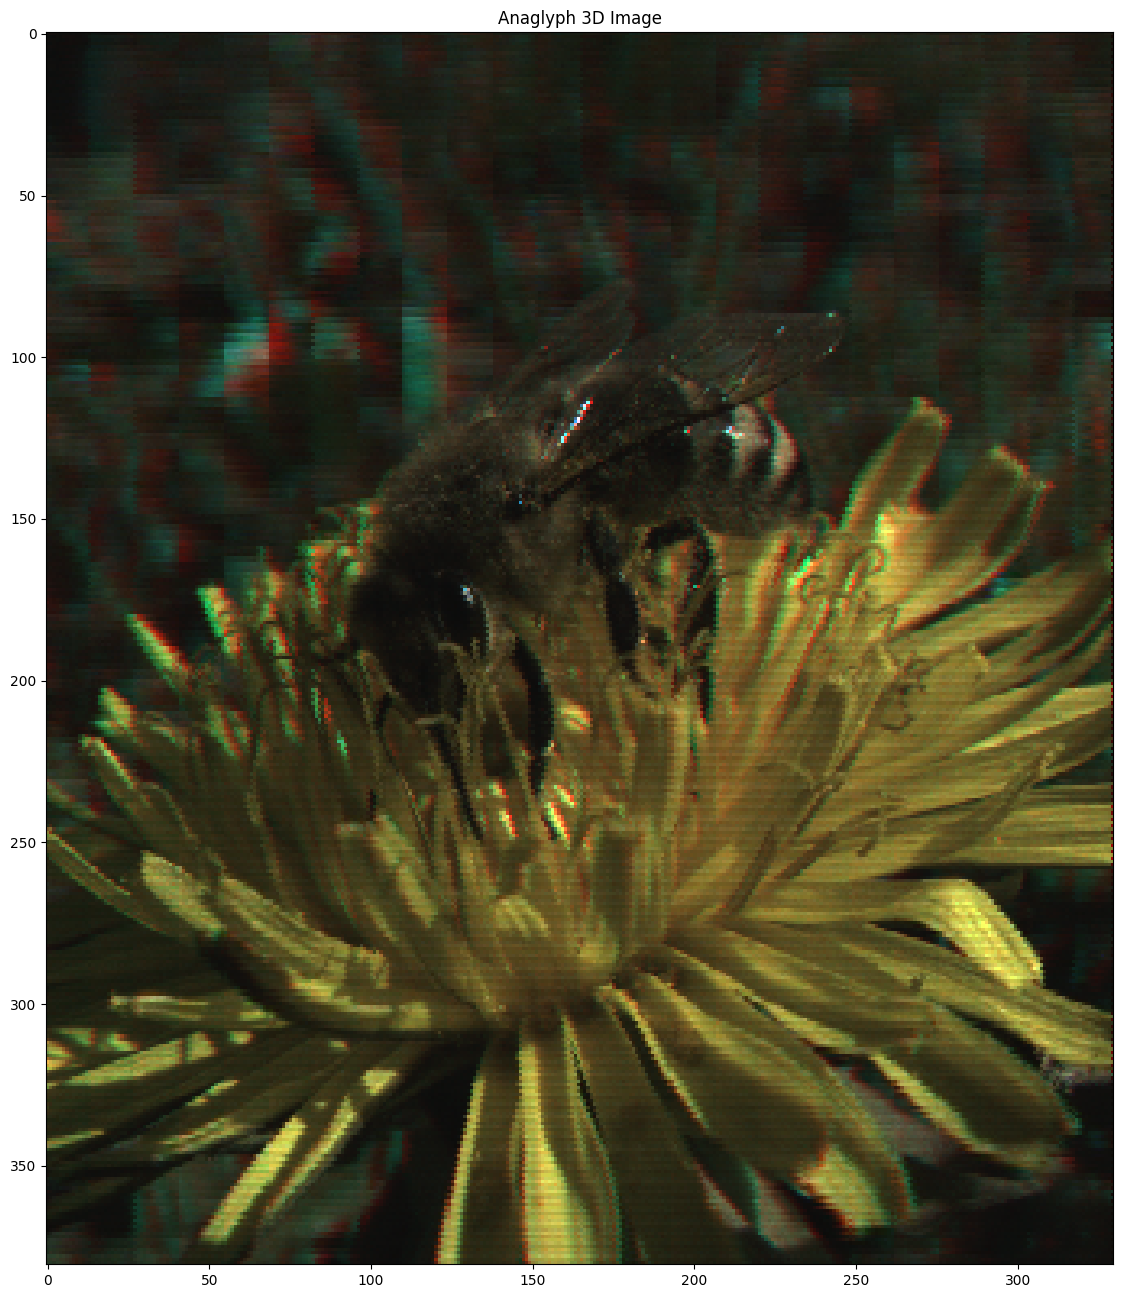

In [ ]:
from skimage.exposure import match_histograms
left_view = baseline_move(image_interpolated, plenoptic_image_config, 0, -4)
right_view = baseline_move(image_interpolated, plenoptic_image_config, 0, 4)

right_view = match_histograms(right_view, left_view, channel_axis=-1)

anaglyph = np.zeros_like(left_view)
anaglyph[:, :, 0] = left_view[:, :, 0]
anaglyph[:, :, 1] = right_view[:, :, 1]
anaglyph[:, :, 2] = right_view[:, :, 2]

plt.figure(figsize=(16, 16))
plt.imshow(anaglyph)
plt.title("Anaglyph 3D Image")
plt.show()

## The end?

![dear_princess_celestia.jpg](dear_princess_celestia.jpg)

*Пожалуйста, напишите ниже в свободной форме вашу боль от задания: что понравилось, что не понравилось*

красиво